# Семинар 11

# Robust PCA

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib
import cvxpy as cvx

In [ ]:
matplotlib.use('Agg')
params = {'legend.fontsize': 20,
          'legend.handlelength': 4,
          "axes.labelsize": 45,
          "xtick.labelsize": 25,
          "ytick.labelsize": 25,
          "lines.linewidth": 4,
           "axes.titlesize":30}
matplotlib.rcParams.update(params)

In [ ]:
class AccProxGM(ProxGM):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def solve(self, x0, f, gradf, g_prox, tol=1e-3, max_iter=10000):
        x = x0.copy()
        x_prev = x.copy()
        self.history = [(x, time.time())]
        t_prev = 1
        t_next = (1 + np.sqrt(1 + 4 * t_prev**2)) / 2.
        for i in range(max_iter):
            w = (t_prev - 1) / t_next
            x, x_prev = x + w * (x - x_prev), x
            t_prev = t_next
            t_next = (1 + np.sqrt(1 + 4 * t_prev**2)) / 2.
            if self.fix_lam is None:
                x = self.backtracking(x, f, gradf, g_prox)
            else:
                x_ = x - self.fix_lam * gradf(x)
                x = g_prox(x_, self.fix_lam)
            self.history.append((x, time.time()))
        return x

## 5. Matrix decomposition

\begin{align*}
& \min \phi_1(X_1) + \gamma_2 \phi_2(X_2) + \ldots + \gamma_N \phi_N(X_N) \\
\text{s.t. } & X_1 + \ldots + X_N = A
\end{align*}

- Представление матрицы в виде суммы хорошо-структурированных матриц
- **Robust PCA**: $A = L + S$, где 
    - $L$ есть малоранговая матрица
    - $S$ есть разреженная матрица

Задача матричного разложения в форме безусловной оптимизации:
\begin{align*}
& \min \|X-X_1 - X_2\|_F^2 + \gamma_1 \|X_1\|_* + \gamma_2 \|X_2\|_{\ell_1}\\
\end{align*}

$$\text{prox}_{\gamma_1 \|X_1\|_* + \gamma_2 \|X_2\|_{\ell_1}\\} ((X_1, X_2)) = (prox_{\gamma_1 \|X_1\|_*} ( X_1),\text{prox}_{\gamma_2 \|X_2\|_{\ell_1}\\} (X_2)) $$

$$ \min \gamma_1 \|X_1\|_* + \gamma_2 \|X_2\|_{\ell_1}$$

$$\text{s.t. } X = X_1 + X_2$$

In [ ]:
class MatrixDecompose:
    def __init__(self, A, gamma2, gamma3):
        self.A = A
        self.gamma2 = gamma2
        self.gamma3 = gamma3
    
    def F(self, X):
        X0, X1 = X
        gamma2, gamma3 = self.gamma2, self.gamma3
        return self.f(X) + gamma2 * np.sum(np.abs(X0)) + gamma_3 * np.linalg.norm(X[1], "nuc")

    def f(self, X):
        return 1/2 * np.linalg.norm(self.A - X.sum(0), ord="fro")**2

    def gradf(self, X):
        B = X.sum(0) - self.A
        G = np.array([B for _ in X])
        return G

    @staticmethod
    def entry_l1_prox(X, lam):
        return np.sign(X) * np.maximum(np.abs(X) - lam, 0) 

    @staticmethod
    def nuclear_norm_prox(X, lam):
        U, sigma, V = np.linalg.svd(X, full_matrices=False)
        return U.dot(np.diag(np.maximum(sigma - lam, 0))).dot(V)

    def g_prox(self, X, lam):
        X0 = self.entry_l1_prox(X[0], lam*self.gamma2)
        X1 = self.nuclear_norm_prox(X[1], lam*self.gamma3)
        return np.array([X0, X1])

Shape of data = (400, 64, 64)


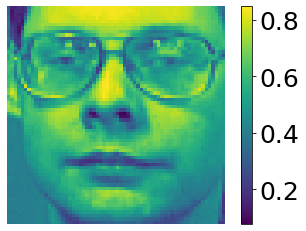

In [ ]:
import sklearn.datasets as skldata
import matplotlib.pyplot as plt
import sklearn.decomposition as skdec

%matplotlib inline
data = skldata.fetch_olivetti_faces()
images = data["images"]
print("Shape of data = {}".format(images.shape))
index = 32
plt.imshow(images[index])
plt.colorbar()
_ = plt.axis("off")

In [ ]:
orig_img = images[index]
img_shape = orig_img.shape

In [ ]:
a = orig_img.reshape(-1)
n = 20
m = len(a)
A = np.outer(a, np.ones(n))

In [ ]:
np.random.seed(1)
S = 20 * np.random.rand(m * n) - 10
S[np.random.rand(m*n) < 0.7] = 0
S = S.reshape(m, n)
V = 0.05 * np.random.randn(m, n)

A = A + S + V
A = np.clip(A, 0, 1)

20 x 64 x 64 -> 20 x 4096

$X = \mathbf{1}_{20} x^\top + X_1 + N$

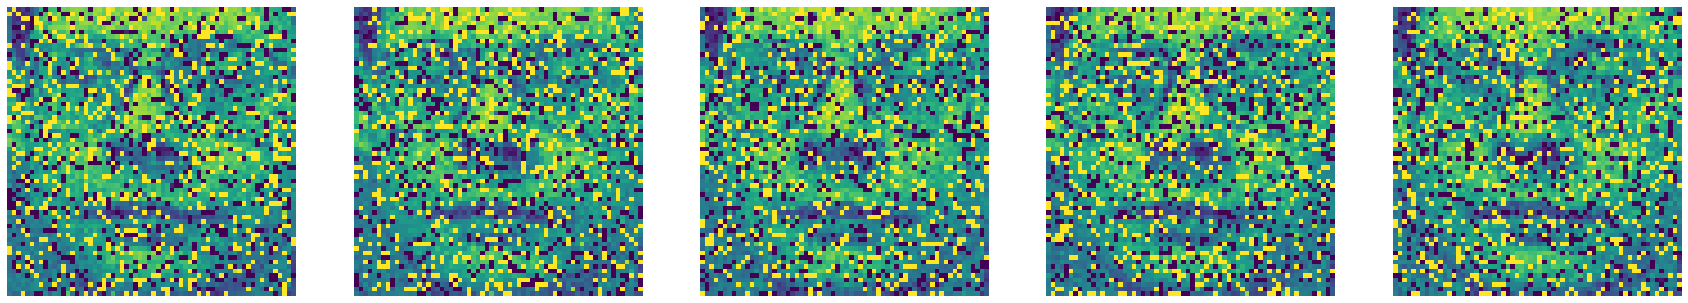

In [ ]:
img_size = 30
num_pic = min(n, 5)
fig, ax = plt.subplots(1, num_pic, figsize=(img_size, img_size * num_pic))
ind = 0
for ind in range(num_pic):
    ax[ind].imshow(A[:, ind].reshape(*img_shape))
    ax[ind].axis("off")

In [ ]:
max_gamma_3 = np.linalg.norm(A, ord="nuc")
gamma_3 = 0.007 * max_gamma_3
max_gamma_2 = np.max(np.abs(A))
gamma_2 = 0.05 * max_gamma_2

In [ ]:
num_iter = 100
methods = []

X0 = np.array([np.zeros((m, n)), np.zeros((m, n))])
problem = MatrixDecompose(A, gamma_2, gamma_3)
method = AccProxGM(fix_lam=None, name="AccProxGM")
X_apm = method.solve(X0, problem.f, problem.gradf, problem.g_prox, max_iter=num_iter)
methods.append(method)
print("f* = {}".format(problem.F(X_apm)))
print("Rank of the low-rank term = {}".format(np.linalg.matrix_rank(X_apm[1])))
print("Number of nnz in sparse term = {}".format(np.sum(X_apm[0] != 0)))

f* = 1168.0869033406389
Rank of the low-rank term = 1
Number of nnz in sparse term = 45752


In [ ]:
U, s, V = np.linalg.svd(A, full_matrices=False)
s[s<s.max()] = 0
PCA_reconstruct = U @ np.diag(s) @ V

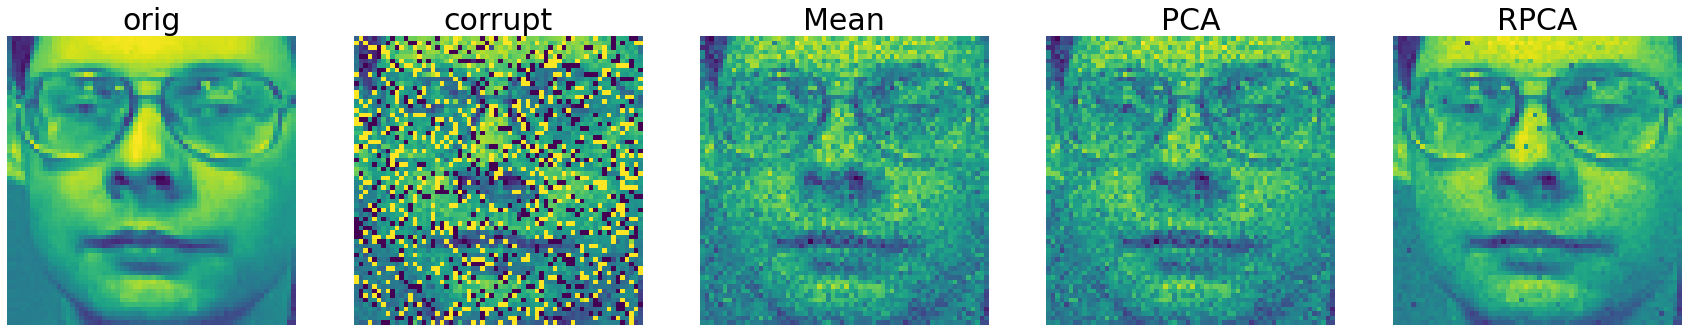

In [ ]:
results = [("orig", images[index].reshape(-1)),
           ("corrupt", A[:, 0]),
           ("Mean", A.mean(axis=-1)),
           ("PCA", PCA_reconstruct[:, 0]),
           ("RPCA", X_apm[1][:, 0])]

img_size = 30
fig, ax = plt.subplots(1, len(results), figsize=(img_size, img_size * len(results)))
ind = 0
for ind, (name, img) in enumerate(results):
    ax[ind].imshow(img.reshape(*img_shape))
    ax[ind].set_title(name)
    ax[ind].axis("off")

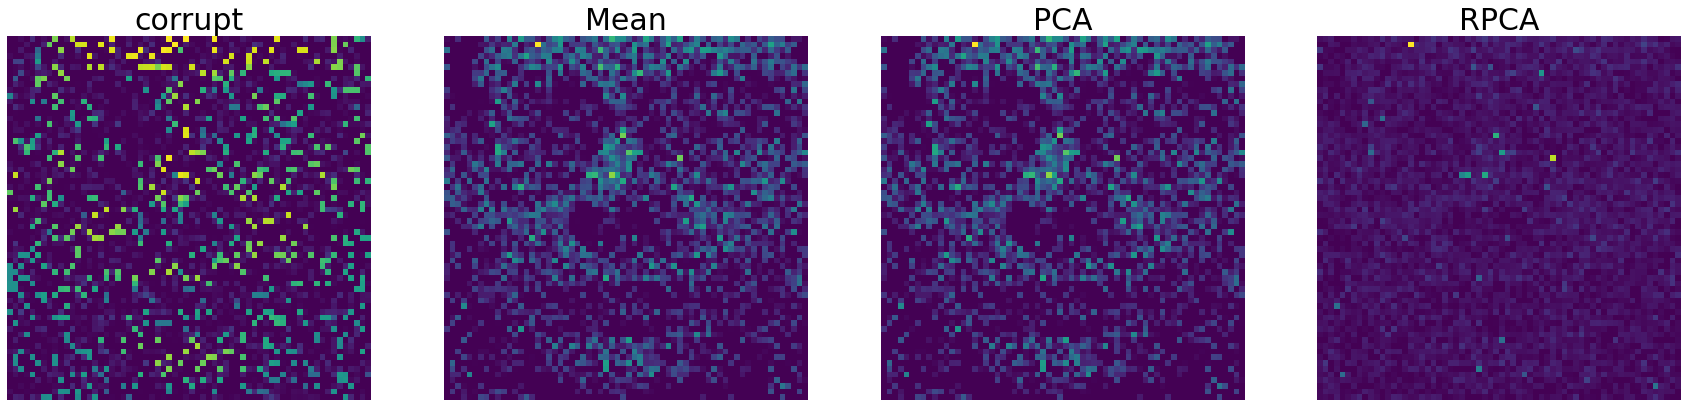

In [ ]:
fig, ax = plt.subplots(1, len(results)-1, figsize=(img_size, img_size * (len(results))-1))
ind = 0
for ind, (name, img) in enumerate(results[1:]):
    ax[ind].imshow(np.clip(images[index]-img.reshape(*img_shape), 0, 1))
    ax[ind].set_title(name)
    ax[ind].axis("off")

In [ ]:
for ind, (name, img) in enumerate(results[1:]):
    print("{}\t{}".format(name, np.linalg.norm(img.reshape(64,64)-images[index], ord=1)))

corrupt	15.626114200483737
Mean	4.958852952312158
PCA	4.850087969018796
RPCA	2.4713613739348004
